In [291]:
%load_ext autoreload
%autoreload 2
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [292]:
file10 = uproot.open("AODSkimmer/corrected_signal_2022_files/Signal_Mchi-10p5_dMchi-1p0_ctau-1000_output.root")
dir10= file10["ntuples"]    
tree10 = dir10["outT"]

In [293]:
pdgs10 = tree10["GenPart_ID"].array()
mask10 = pdgs10==1000023

In [294]:
#Gamma calculation
energy10 = tree10["GenPart_e"].array()
energychi210=energy10[mask10]

mass10 = tree10["GenPart_mass"].array()
mchi210 = mass10[mask10]

gamma10= energychi210/mchi210

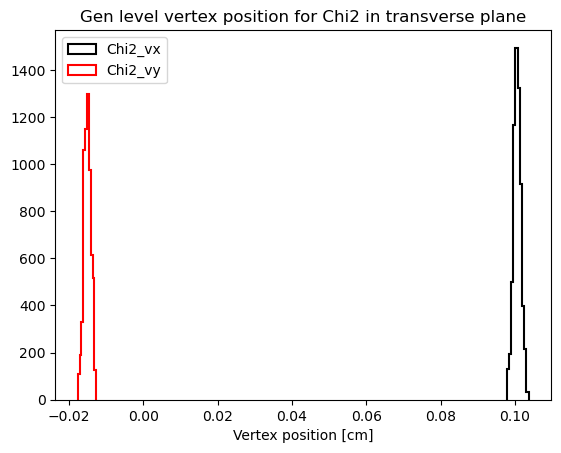

In [295]:
vx_chi2 = ak.flatten(tree10['GenPart_vx'].array()[mask10])
vy_chi2 = ak.flatten(tree10['GenPart_vy'].array()[mask10])
vz_chi2 = ak.flatten(tree10['GenPart_vz'].array()[mask10])


plt.hist(vx_chi2,histtype="step",color = 'black', linewidth=1.5, label="Chi2_vx")
plt.hist(vy_chi2,histtype="step",color = 'red', linewidth=1.5, label="Chi2_vy")

plt.xlabel("Vertex position [cm]")
plt.legend()
plt.title("Gen level vertex position for Chi2 in transverse plane")
plt.show()

Text(0.5, 0, 'Chi2_vz [cm]')

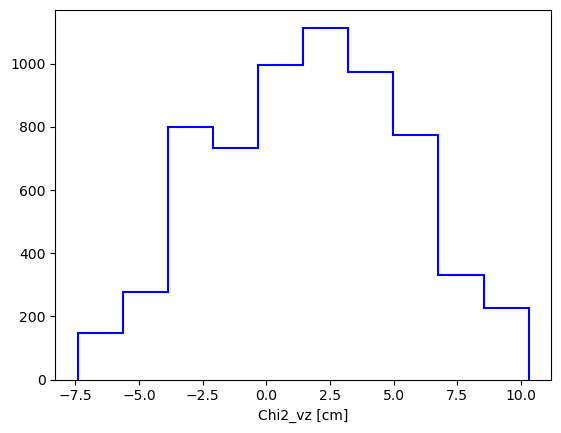

In [296]:
plt.hist(vz_chi2,histtype="step",color = 'blue', linewidth=1.5)
plt.xlabel("Chi2_vz [cm]")

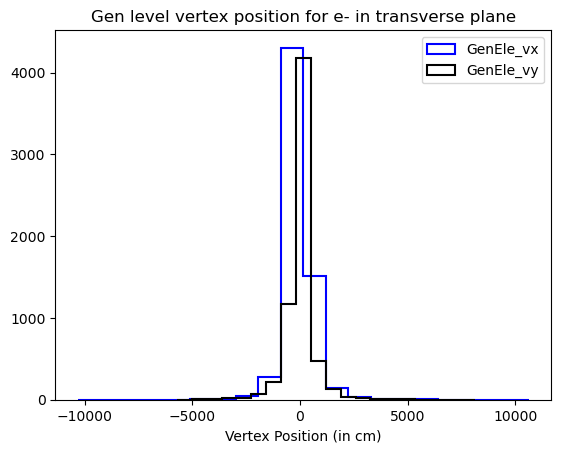

In [297]:
vx_genele = tree10['GenEle_vx'].array() 
vy_genele = tree10['GenEle_vy'].array() 
vz_genele = tree10['GenEle_vz'].array() 

plt.hist(vx_genele,histtype="step",color = 'blue', bins=20, linewidth=1.5, label="GenEle_vx")
plt.hist(vy_genele,histtype="step",color = 'black', bins=20, linewidth=1.5, label="GenEle_vy")

plt.xlabel("Vertex Position (in cm)")
plt.title("Gen level vertex position for e- in transverse plane")
plt.legend()
plt.show()

Text(0.5, 0, 'gen_vz [cm]')

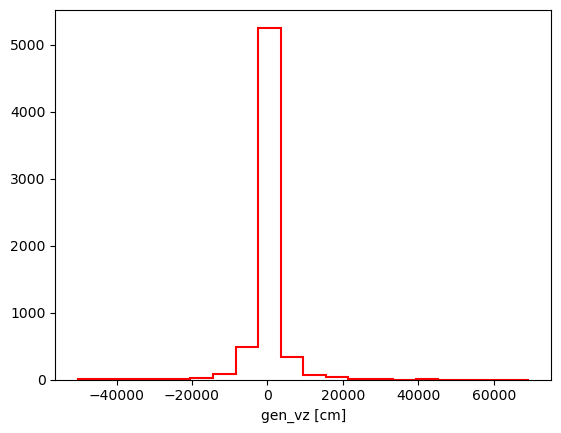

In [298]:
plt.hist(vz_genele,histtype="step",color = 'red', bins=20, linewidth=1.5, label="GenEle_vz")
plt.xlabel("gen_vz [cm]")

In [299]:
decaylength_chi2 = np.sqrt( (vx_genele-vx_chi2)**2 + (vy_genele-vy_chi2)**2 + (vz_genele-vz_chi2)**2 )  #in cm
print (decaylength_chi2)

[191, 807, 785, 3.24e+03, 1.01e+03, 432, ... 4.89e+03, 6.43e+03, 88.3, 473, 14.9]


In [ ]:
# gamma= energychi2/mchi2
# decaylength_chi2 = np.sqrt( (vx_genele-vx_chi2)**2 + (vy_genele-vy_chi2)**2 + (vz_genele-vz_chi2)**2 )  #in cm
# ctau=decaylength_chi2/gamma

In [300]:
ctau=decaylength_chi2/gamma10

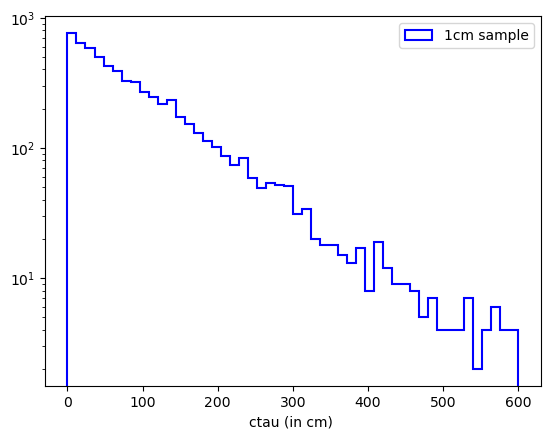

In [301]:
plt.hist(ctau,histtype="step",color = 'blue',linewidth=1.5, range=(0,600),bins=50, log=True, label="1cm sample")
plt.xlabel("ctau (in cm) ")
plt.legend()
plt.savefig("ctau10", dpi=300)

[665. 516. 518. 450. 402. 353. 324. 292. 265. 243. 221. 203. 193. 187.
 167. 129. 116. 111. 100.  78.  82.  73.  62.  63.  54.  33.  45.  47.
  50.  36.  29.  21.  21.  19.  17.  14.  11.  10.  14.  14.   7.  16.
   8.  10.   8.   6.   7.   4.   5.   6.   4.   2.   3.   6.   2.   1.
   7.   3.   3.   4.]
[665. 516. 518. 450. 402. 353. 324. 292. 265. 243. 221. 203. 193. 187.
 167. 129. 116. 111. 100.  78.  82.  73.  62.  63.  54.  33.  45.  47.
  50.  36.  29.  21.  21.  19.  17.  14.  11.  10.  14.  14.   7.  16.
   8.  10.   8.   6.   7.   4.   5.   6.   4.   2.   3.   6.   2.   1.
   7.   3.   3.   4.]
60
60


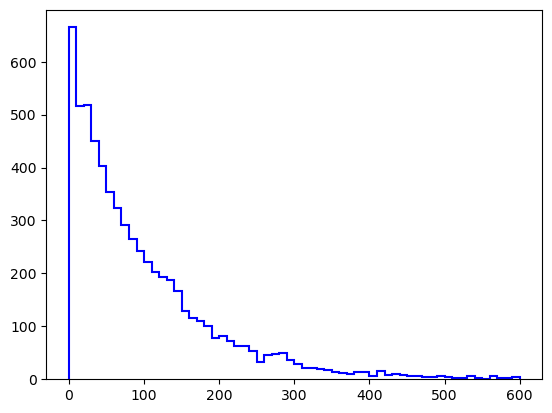

In [302]:
#Fitting part
y,x, _= plt.hist(ctau,histtype="step",color = 'blue',linewidth=1.5, range=(0,600),bins=60)

print (y)

mask = y>0
ym = y[mask]
print (ym)

y_fit = np.log(y[mask]) #y for fit
print (len(y_fit))
ct= (x[:-1] + x[1:])/2   #the ct values (in cm)
x_fit=ct[mask]  #x for fit

sigma = 1/(np.sqrt(ym)) #sigma for fit
print (len(sigma))

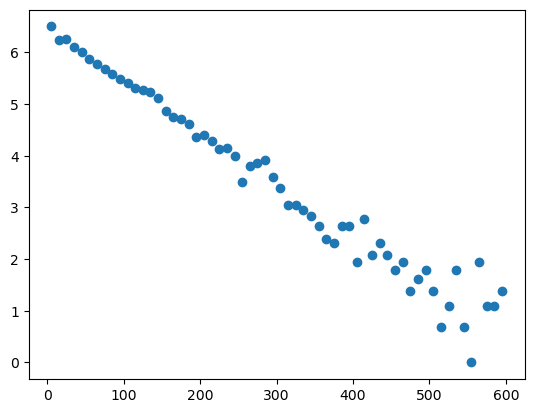

In [303]:
plt.scatter(x_fit, y_fit)

In [304]:
def linear(x_fit,m,b):
    return (m*(x_fit)+b)

from scipy.optimize import curve_fit

params, cov = curve_fit(linear,x_fit,y_fit, sigma=sigma)
m_fit, b_fit = params

ctau0 = -1/m_fit

print ("Fitted b =", b_fit) 
print("Fitted m =", m_fit)  
print("ctau0 =", ctau0)

Fitted b = 6.45994324167597
Fitted m = -0.009971180317183002
ctau0 = 100.28902980289439


In [305]:
#For goodness of fit:
residuals = y_fit - linear(x_fit, m_fit, b_fit)

chi2 = np.sum((residuals / sigma)**2)

ndof = len(y_fit) - len(params)   # N - number of fit parameters
chi2_red = chi2 / ndof

print("chi2 =", chi2)
print("ndof =", ndof)
print("chi2/ndof =", chi2_red)

chi2 = 61.948751000840545
ndof = 58
chi2/ndof = 1.0680819138075957


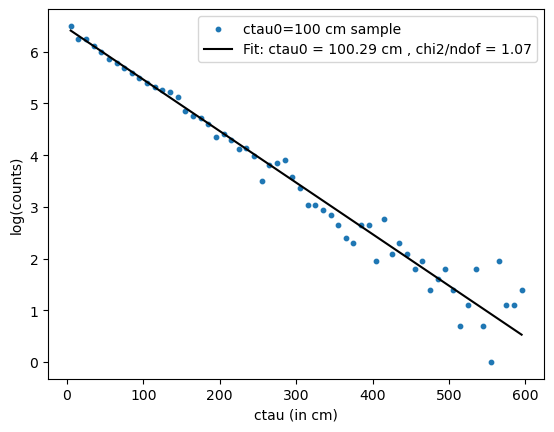

<Figure size 640x480 with 0 Axes>

In [306]:
plt.scatter(x_fit, y_fit, s=10, label="ctau0=100 cm sample")
plt.plot(x_fit, linear(x_fit, m_fit, b_fit),color='black',
         label=f"Fit: ctau0 = {ctau0:.2f} cm , chi2/ndof = {chi2/ndof:.2f}")



# plt.plot(x_fit, linear(x_fit, m, c), color="red",
#          label=f"fit: ctau0 = {ctau0:.1f}")
plt.xlabel("ctau (in cm)")
plt.ylabel("log(counts)")
plt.legend()
plt.show()

plt.savefig("ctauFIT1cm1000mm.png", dpi=300)